In [4]:
!pip install rioxarray geopandas cftime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.8 MB/s eta 0:00:00:00:01


Curah Hujan Wilayah Kebumen CHIRPS Date 29-1-2007


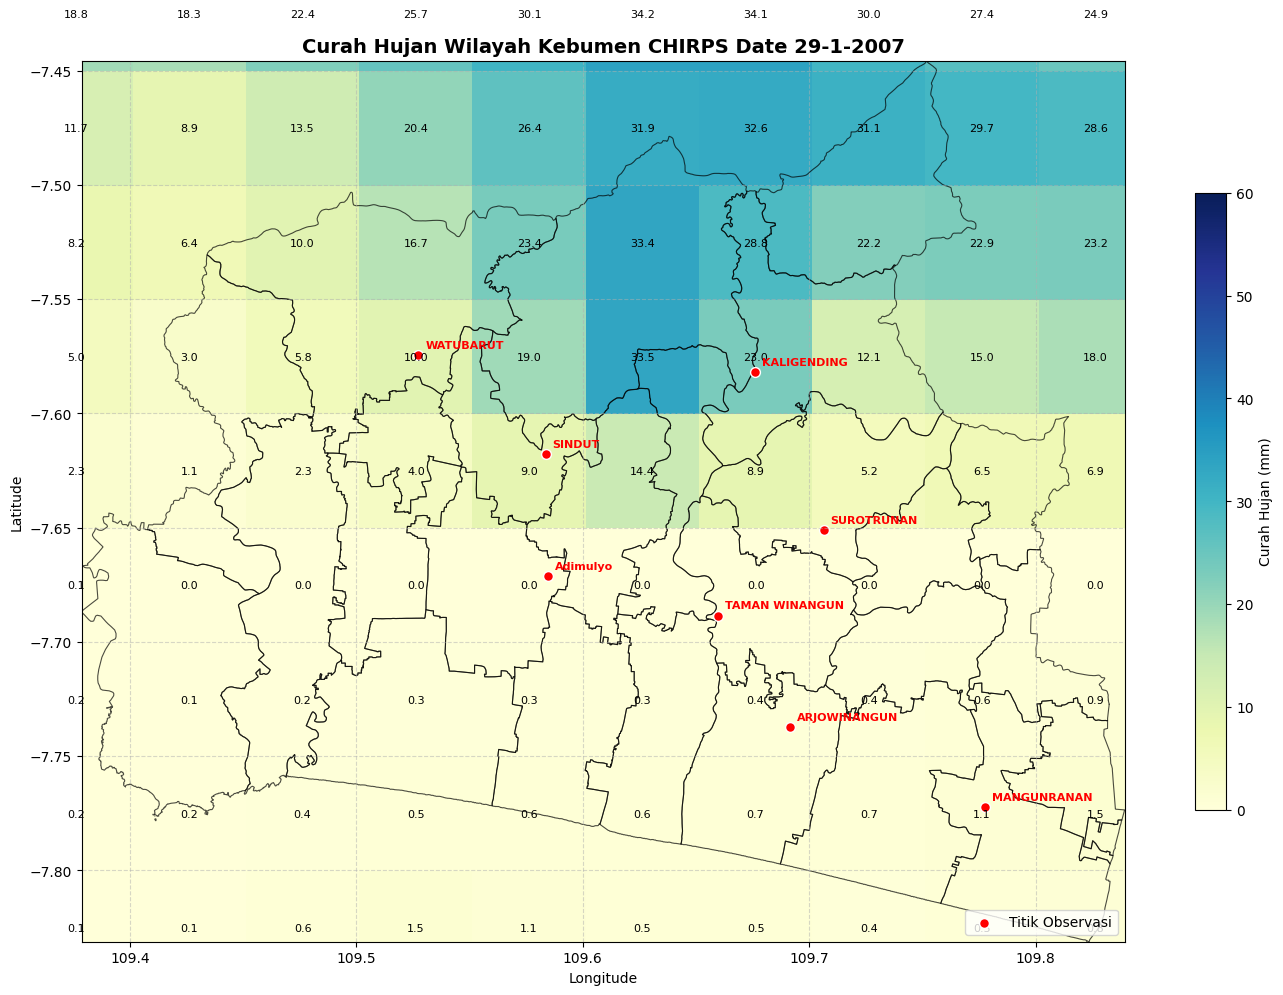

In [7]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PERSIAPAN DATA (GEOJSON & NETCDF)
# ==========================================
year = 2007  # Disesuaikan dengan contoh direktori Anda
month = 1
day = 29

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "33.05_kecamatan.geojson"
)

# --- PERUBAHAN DIREKTORI & FORMAT FILE DI SINI ---
# Contoh target: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/chirps/2013/2013_01/chirps_01_01_2013.nc
file_nc = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "chirps", 
    f"{year}", f"{year}_{month:02d}", f"chirps_{day:02d}_{month:02d}_{year}.nc"
)

# Data Koordinat Titik
data_titik = {
    'Nama': ['MANGUNRANAN', 'Adimulyo', 'ARJOWINANGUN', 'KALIGENDING', 'SUROTRUNAN', 'TAMAN WINANGUN', 'SINDUT', 'WATUBARUT'],
    'Lon': [109.777438, 109.584578, 109.691462, 109.676111, 109.706417, 109.659678, 109.583611, 109.527400],
    'Lat': [-7.772229, -7.671261, -7.737322, -7.581939, -7.651139, -7.688477, -7.618002, -7.574630]
}

gdf = gpd.read_file(file_geojson)

# Buka file NetCDF
da_global = rioxarray.open_rasterio(file_nc, masked=True).squeeze()

# Safety Check: Pastikan NetCDF terbaca CRS-nya. Jika kosong, paksakan ke WGS84.
if da_global.rio.crs is None:
    da_global.rio.write_crs("EPSG:4326", inplace=True)

# ==========================================
# 2. PENYELARASAN CRS
# ==========================================
if gdf.crs != da_global.rio.crs:
    gdf = gdf.to_crs(da_global.rio.crs)

# ==========================================
# 3. CLIPPING (Bounding Box)
# ==========================================
batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds
da_kebumen = da_global.rio.clip_box(
    minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
)

# ==========================================
# 4. VISUALISASI
# ==========================================
fig, ax = plt.subplots(figsize=(15, 10))

# Plot Raster CHIRPS
da_kebumen.plot(
    ax=ax, 
    cmap='YlGnBu', 
    vmax=60,
    vmin=0, 
    cbar_kwargs={'label': 'Curah Hujan (mm)', 'shrink': 0.7}
)

# Plot Garis Tepi GeoJSON
gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.7)

# --- TAMBAHAN: PLOT LABEL ANGKA PIKSEL ---
x_coords = da_kebumen.x.values
y_coords = da_kebumen.y.values
hujan_values = da_kebumen.values

for i in range(len(y_coords)):
    for j in range(len(x_coords)):
        nilai = hujan_values[i, j]
        if not np.isnan(nilai):
            text = ax.text(x_coords[j], y_coords[i], f'{nilai:.1f}',
                           ha="center", va="center", color="black", 
                           fontsize=8, fontweight='normal')

# --- TAMBAHAN: PLOT TITIK KOORDINAT ---
ax.scatter(
    data_titik['Lon'], 
    data_titik['Lat'], 
    color='red', 
    marker='o', 
    s=50, 
    edgecolor='white', 
    label='Titik Observasi'
)

# Menambahkan Label Nama pada Tiap Titik
for i, txt in enumerate(data_titik['Nama']):
    ax.annotate(
        txt, 
        (data_titik['Lon'][i], data_titik['Lat'][i]), 
        fontsize=8, 
        xytext=(5, 5), 
        textcoords='offset points',
        fontweight='bold',
        color='red' 
    )

# Kunci Ukuran Kanvas
ax.set_xlim(batas_kiri, batas_kanan)
ax.set_ylim(batas_bawah, batas_atas)

title = f'Curah Hujan Wilayah Kebumen CHIRPS Date {day}-{month}-{year}'
print(title)
plt.title(title, fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Ditemukan 31 file NetCDF untuk Bulan 01 Tahun 2014.
Memulai proses ekstraksi dan pemotongan data...
Mengakumulasi curah hujan selama satu bulan...
Peta Akumulasi Curah Hujan Bulanan CHIRPS - Kebumen
Bulan: 01 Tahun: 2014


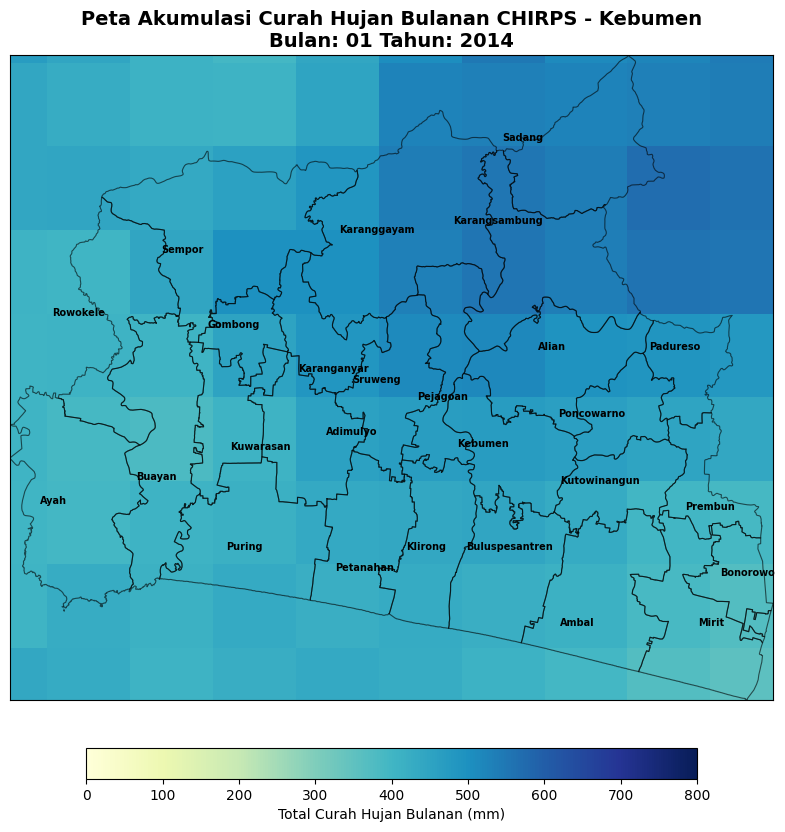

Selesai! Peta berhasil di-render dan disimpan sebagai Akumulasi_CHIRPS_Kebumen_2014_01.tif


In [14]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

# ==========================================
# 1. PARAMETER WAKTU & LOKASI
# ==========================================
year = 2014  # Sesuaikan dengan tahun data Anda
month = 1    # Sesuaikan dengan bulan data Anda

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON (Asumsi berada di folder dataset Kaggle)
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "33.05_kecamatan.geojson"
)

# --- PERUBAHAN DIREKTORI DI SINI ---
# Menyesuaikan dengan format: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/chirps/2013/2013_01/
folder_chirps = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "chirps", 
    f"{year}", f"{year}_{month:02d}"
)

# Buka GeoJSON dan ambil Bounding Box (Kotak Batas)
gdf = gpd.read_file(file_geojson)
batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds

# ==========================================
# 2. MENCARI SEMUA FILE DI BULAN TERSEBUT
# ==========================================
# Menggunakan pola (pattern) untuk mencari file NetCDF (contoh: chirps_*_01_2013.nc)
pola_pencarian = os.path.join(folder_chirps, f"chirps_*_{month:02d}_{year}.nc")
daftar_file = glob.glob(pola_pencarian)
daftar_file.sort() # Pastikan urutan harinya benar dari tanggal awal sampai akhir bulan

print(f"Ditemukan {len(daftar_file)} file NetCDF untuk Bulan {month:02d} Tahun {year}.")

if len(daftar_file) == 0:
    print("⚠️ Peringatan: Tidak ada file yang ditemukan. Pastikan path direktori sudah benar!")
else:
    # ==========================================
    # 3. LOOPING: MEMBACA DAN MEMOTONG PER HARI
    # ==========================================
    print("Memulai proses ekstraksi dan pemotongan data...")
    data_harian_terpotong = []

    # Kita buka file global, potong ke Kebumen, lalu simpan potongan kecilnya saja ke RAM
    for file in daftar_file:
        # Buka file
        da_hari_ini = rioxarray.open_rasterio(file, masked=True).squeeze()
        
        # Safety Check: Paksakan CRS ke WGS84 jika NetCDF kehilangan atribut spasialnya
        if da_hari_ini.rio.crs is None:
            da_hari_ini.rio.write_crs("EPSG:4326", inplace=True)
        
        # Samakan CRS jika GeoJSON berbeda dengan data raster
        if file == daftar_file[0] and gdf.crs != da_hari_ini.rio.crs:
            gdf = gdf.to_crs(da_hari_ini.rio.crs)
        
        # Potong menggunakan clip_box
        da_potongan = da_hari_ini.rio.clip_box(
            minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
        )
        
        # Masukkan hasil potongan ke dalam list (keranjang)
        data_harian_terpotong.append(da_potongan)
        
        # Tutup file global untuk membebaskan memori
        da_hari_ini.close()

    # ==========================================
    # 4. PROSES AKUMULASI (PENJUMLAHAN BULANAN)
    # ==========================================
    print("Mengakumulasi curah hujan selama satu bulan...")
    # Gabungkan potongan harian menjadi satu dimensi 'time'
    da_gabungan = xr.concat(data_harian_terpotong, dim='time')

    # Jumlahkan dari atas ke bawah (menembus dimensi waktu)
    # skipna=True memastikan jika ada data satelit yang bolong di 1 hari, penjumlahan tidak error
    da_akumulasi_bulanan = da_gabungan.sum(dim='time', skipna=True)

    # ==========================================
    # 5. VISUALISASI PETA AKUMULASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(8, 10))

    # Plot Raster Akumulasi CHIRPS
    da_akumulasi_bulanan.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmin=0, 
        vmax=800, # Batas maksimal disesuaikan untuk skala bulanan (sesuaikan jika perlu)
        cbar_kwargs={
            'label': 'Total Curah Hujan Bulanan (mm)', 
            'orientation': 'horizontal', 
            'pad': 0.05, 
            'shrink': 0.8
        }
    )

    # Plot Garis Tepi GeoJSON (Dibuat agak tipis agar elegan)
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.6)

    # Plot Label Kecamatan
    koordinat_kecamatan = {
        'Adimulyo': (109.585, -7.671),
        'Alian': (109.706, -7.620),
        'Ambal': (109.721, -7.785),
        'Ayah': (109.405, -7.712),
        'Bonorowo': (109.824, -7.755),
        'Buayan': (109.467, -7.698),
        'Buluspesantren': (109.680, -7.740),
        'Gombong': (109.514, -7.607),
        'Karanganyar': (109.574, -7.633),
        'Karanggayam': (109.600, -7.550),
        'Karangsambung': (109.673, -7.545),
        'Kebumen': (109.664, -7.678),
        'Klirong': (109.630, -7.740),
        'Kutowinangun': (109.735, -7.700),
        'Kuwarasan': (109.530, -7.680),
        'Mirit': (109.802, -7.785),
        'Padureso': (109.780, -7.620),
        'Pejagoan': (109.640, -7.650),
        'Petanahan': (109.593, -7.752),
        'Poncowarno': (109.730, -7.660),
        'Prembun': (109.801, -7.716),
        'Puring': (109.520, -7.740),
        'Rowokele': (109.420, -7.600),
        'Sadang': (109.688, -7.495),
        'Sempor': (109.483, -7.562),
        'Sruweng': (109.600, -7.640)
    }

    for nama_kec, (lon, lat) in koordinat_kecamatan.items():
        ax.text(
            lon, lat, nama_kec, 
            fontsize=7, 
            ha='center', va='center', 
            color='black', 
            fontweight='bold',
        )

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    # Trik Sosmed 2: Hapus angka koordinat pinggir yang bikin ruwet
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    title = f'Peta Akumulasi Curah Hujan Bulanan CHIRPS - Kebumen\nBulan: {month:02d} Tahun: {year}'
    print(title)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # OPSIONAL: Menyimpan hasil akumulasi ini menjadi file TIFF baru
    output_filename = f"Akumulasi_CHIRPS_Kebumen_{year}_{month:02d}.tif"
    da_akumulasi_bulanan.rio.to_raster(output_filename)
    print(f"Selesai! Peta berhasil di-render dan disimpan sebagai {output_filename}")

In [9]:
import xarray as xr
import rioxarray
import pandas as pd
import glob
import os

# 1. TENTUKAN KOORDINAT TARGET (Misal: Pusat Kabupaten Kebumen)
# Pastikan koordinat ini sesuai dengan Sistem Koordinat (CRS) file Anda
lat_target = -7.668
lon_target = 109.651
tahun_target = 2026

# 2. DAFTAR SEMUA FILE TIFF
# Ganti dengan path folder tempat Anda menyimpan hasil download
path_folder = r"D:\Kuliah Semester 7\SKRIPSI\CHIRPS_" + str(tahun_target)
semua_file = glob.glob(os.path.join(path_folder, "*.tif"))
semua_file.sort() # Penting agar urutan waktunya benar

print(f"Ditemukan {len(semua_file)} file. Memulai proses penggabungan...")

# 3. BUKA SEMUA FILE SEBAGAI SATU DATASET (Multi-File Dataset)
# Kita tambahkan dimensi baru bernama 'time' untuk setiap file
def pre_process(ds):
    # Mengambil tanggal dari nama file (Asumsi format nama file CHIRPS mengandung tanggal)
    # Contoh: chirps-v3.0.rnl.2025.01.01.tif
    # Jika nama file tidak mengandung tanggal, Anda harus menyesuaikan bagian ini
    nama_file = ds.encoding['source']
    tanggal_str = os.path.basename(nama_file).split('.')[3:6] # Ambil 2025, 01, 01
    tanggal = pd.to_datetime("-".join(tanggal_str))
    
    return ds.expand_dims(time=[tanggal])

# Gunakan open_mfdataset untuk performa tinggi
ds_combined = xr.open_mfdataset(semua_file, preprocess=pre_process, engine="rasterio")

# 4. EKSTRAKSI SATU PIXEL (POINT EXTRACTION)
# method="nearest" digunakan jika koordinat tidak pas persis di tengah piksel
print(f"Mengekstrak data di koordinat: {lat_target}, {lon_target}")
point_data = ds_combined.sel(x=lon_target, y=lat_target, method="nearest")

# 5. KONVERSI KE PANDAS DATAFRAME & SIMPAN KE CSV
# Ubah ke DataFrame TANPA menggunakan argumen name
df_hasil = point_data.to_dataframe().reset_index()

# Catatan: Secara default, rioxarray (pembaca TIFF) menamai kolom datanya dengan 'band_data'
# Kita ubah nama kolom 'band_data' tersebut menjadi 'curah_hujan'
df_hasil = df_hasil.rename(columns={'band_data': 'curah_hujan'})

# Memilih kolom yang penting saja (membuang kolom x, y, band, spatial_ref yang tidak perlu)
# Gunakan try-except ringan untuk memastikan jika nama variabel bawaannya berbeda
try:
    df_hasil = df_hasil[['time', 'curah_hujan']]
except KeyError:
    # Jika error, berarti nama variabel bawaan TIFF-nya bukan 'band_data'.
    # Kita ambil kolom pertama dan terakhir (waktu dan nilai) secara otomatis.
    kolom_nilai = df_hasil.columns[-1]
    df_hasil = df_hasil.rename(columns={kolom_nilai: 'curah_hujan'})
    df_hasil = df_hasil[['time', 'curah_hujan']]

# Simpan ke CSV
nama_csv = f"timeseries_hujan_kebumen_{tahun_target}.csv"
df_hasil.to_csv(nama_csv, index=False)

print(f"🎉 Selesai! Data tersimpan di {nama_csv}")
print(df_hasil.head())

Ditemukan 90 file. Memulai proses penggabungan...
Mengekstrak data di koordinat: -7.668, 109.651
🎉 Selesai! Data tersimpan di timeseries_hujan_kebumen_2026.csv
        time  curah_hujan
0 2026-01-01    38.529789
1 2026-01-02    16.191710
2 2026-01-03    11.266408
3 2026-01-04     6.460074
4 2026-01-05     1.136087
